# 02b - Torus Skeletonization Demo

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

from mcf2swc import *

import logging
logging.basicConfig(level=logging.INFO)

## Create and Visualize Torus

In [2]:
# Create a cylinder mesh
mesh = example_mesh(kind="torus")

mm = MeshManager(mesh)
mm.print_mesh_analysis()
mm.visualize_mesh_3d(title="Original Torus", backend="plotly")


INFO:mcf2swc.mesh:Mesh Analysis Report
INFO:mcf2swc.mesh:====================
INFO:mcf2swc.mesh:
Geometry:
INFO:mcf2swc.mesh:  * Vertices: 512
INFO:mcf2swc.mesh:  * Faces: 1024
INFO:mcf2swc.mesh:  * Components: 1
INFO:mcf2swc.mesh:  * Volume: 76.45
INFO:mcf2swc.mesh:  * Bounds: [-5.0, -5.0, -1.0] to [5.0, 5.0, 1.0]
INFO:mcf2swc.mesh:
Mesh Quality:
INFO:mcf2swc.mesh:  * Watertight: True
INFO:mcf2swc.mesh:  * Winding Consistent: True
INFO:mcf2swc.mesh:  * Normal Direction: outward
INFO:mcf2swc.mesh:  * Duplicate Vertices: 0
INFO:mcf2swc.mesh:  * Degenerate Faces: 0
INFO:mcf2swc.mesh:
Topology:
INFO:mcf2swc.mesh:  * Genus: 1
INFO:mcf2swc.mesh:  * Euler Characteristic: 0
INFO:mcf2swc.mesh:
No issues detected
INFO:mcf2swc.mesh:
Recommendation:
INFO:mcf2swc.mesh:  Mesh appears to be in good condition.
INFO:mcf2swc.mesh:====================


## Skeletonization

In [3]:
pls = PolylinesSkeleton().from_txt("../data/polylines/torus.polylines.txt")
skel = build_traced_skeleton_graph(mesh, pls, options=TraceOptions(spacing=1))
print(skel)

INFO:mcf2swc.trace:Tracing start: mesh[V=512,F=1024], polylines=1 (pts=33), spacing=1, radius_mode=equivalent_area
INFO:mcf2swc.trace:Polyline 0: input_pts=33 -> samples=26
INFO:mcf2swc.trace:Tracing done: nodes=25, edges=25, samples=26, section=26, fallback=0


SkeletonGraph with 25 nodes and 25 edges


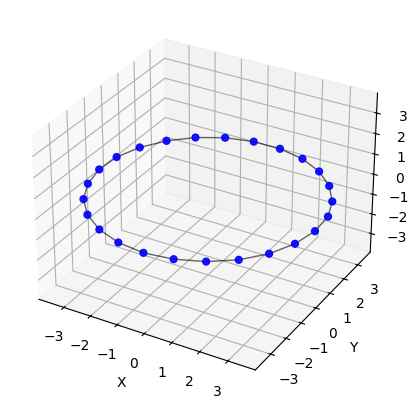

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

In [4]:
skel.plot(node_scale=5)

In [5]:
# write swc to file
skel.to_swc("../data/swc/demo/torus.swc")

'# generated by mcf2swc SkeletonGraph.to_swc\n# dfs_roots=1\n# nodes=25 extra_edges=1 duplicates=1\n# type_index=3\n# CYCLE_BREAK reconnect 26 25\n1 3 3.902691 0.777431 -0.001190 0.992354 -1\n2 3 3.957878 -0.217738 -0.001190 0.985068 1\n3 3 3.775573 -1.196154 -0.001190 0.984808 2\n4 3 3.366060 -2.103717 -0.001190 0.985748 3\n5 3 2.737706 -2.876217 -0.001190 0.985966 4\n6 3 1.930069 -3.458769 -0.001190 0.984835 5\n7 3 1.007791 -3.832742 -0.001190 0.984995 6\n8 3 0.021854 -3.977323 -0.001190 0.986864 7\n9 3 -0.965755 -3.845393 -0.001190 0.985179 8\n10 3 -1.891367 -3.479487 -0.001190 0.984793 9\n11 3 -2.703868 -2.904183 -0.001190 0.985569 10\n12 3 -3.345223 -2.142355 -0.001190 0.986184 11\n13 3 -3.762792 -1.238150 -0.001190 0.984868 12\n14 3 -3.953659 -0.261434 -0.001190 0.984941 13\n15 3 -3.907200 0.733764 -0.001190 0.986595 14\n16 3 -3.592914 1.679016 -0.001190 0.985309 15\n17 3 -3.056858 2.517726 -0.001190 0.984786 16\n18 3 -2.336986 3.205267 -0.001190 0.985408 17\n19 3 -1.468510 3.692

## Summary

The torus segmentation demonstrates:
- **Complex topology**: Middle slices contain multiple segments due to the hole
- **Ring connectivity**: Segments form a circular arrangement in 3D space
- **Genus = 1 handling**: Algorithm correctly identifies separate connected components within slices
- **Spatial relationships**: 3D visualization reveals the donut structure

This showcases the algorithm's ability to handle complex topologies with holes.